
# Análisis Exploratorio de Datos de Acciones
Este script realiza un análisis completo de datos históricos de acciones. 
Incluye carga de datos, limpieza, análisis univariado/bivariado, temporal y por empresa.

## 1. Configuración Inicial
En esta sección se importan las librerías necesarias y se establecen configuraciones básicas para visualización.

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

pd.set_option('display.float_format', lambda x: '{:,.2f}'.format(x))
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

## 2. Carga de Datos
Se carga el archivo Excel que contiene la información de precios históricos de acciones.

In [23]:
file_path = r"C:\\Users\\johan\\OneDrive - Universidad del Norte\\Escritorio\\MachineLearning\\proyecto\\datos\\stock_details_5_years_edit.xlsx"
try:
    df = pd.read_excel(file_path, engine='openpyxl')
    print("✅ Datos cargados exitosamente")
    print("\n🔍 Primeras filas del dataset:")
    print(df.head())
except Exception as e:
    print(f"❌ Error al cargar los datos: {e}")
    exit()

✅ Datos cargados exitosamente

🔍 Primeras filas del dataset:
   Year  Month  Day                   Open                   High  \
0  2018     11   29  43,829,760,572,993.00 438,633,538,041,636.00   
1  2018     11   29 104,769,074,332,185.00 105,519,257,086,357.00   
2  2018     11   29 541,764,984,130,859.00 550,074,996,948,242.00   
3  2018     11   29 837,494,964,599,609.00 844,994,964,599,609.00   
4  2018     11   29 396,927,840,259,795.00 400,649,038,762,231.00   

                     Low                  Close     Volume  Dividends  \
0 426,395,935,832,266.00 430,835,075,378,418.00  167080000       0.00   
1 103,534,594,914,971.00 104,636,131,286,621.00   28123200       0.00   
2 540,999,984,741,211.00 547,290,000,915,527.00   31004000       0.00   
3 826,165,008,544,922.00 836,784,973,144,531.00  132264000       0.00   
4 387,351,954,599,368.00 390,378,532,409,668.00   54917200       0.04   

   Stock Splits Company  
0          0.00    AAPL  
1          0.00    MSFT  
2      

## 3. Limpieza y Preparación de Datos
Aquí se corrigen y eliminan datos faltantes, se crean variables necesarias y se ordena el conjunto.

In [24]:
print("\n🧹 Limpieza y preparación de datos:")
df['Date'] = pd.to_datetime(df[['Year', 'Month', 'Day']])
df = df.sort_values(['Company', 'Date'])
print("\nValores faltantes por columna:")
print(df.isnull().sum())
df = df.dropna(subset=['Open', 'High', 'Low', 'Close', 'Volume'])
duplicates = df.duplicated(subset=['Company', 'Date']).sum()
print(f"\nNúmero de registros duplicados: {duplicates}")


🧹 Limpieza y preparación de datos:

Valores faltantes por columna:
Year            0
Month           0
Day             0
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
Company         0
Date            0
dtype: int64

Número de registros duplicados: 0


## 4. Análisis Univariado
Se examinan las variables numéricas de forma individual mediante estadísticas y visualizaciones.

In [ ]:
print("\n📈 Análisis univariado:")
numeric_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')
print("\n📌 Estadísticas descriptivas:")
print(df[numeric_cols].describe())


📈 Análisis univariado:

📌 Estadísticas descriptivas:
                        Open                   High                    Low  \
count             602,962.00             602,962.00             602,962.00   
mean  354,050,867,559,971.94 357,099,597,945,996.62 356,198,787,147,536.69   
std   262,875,719,040,279.28 262,224,644,898,754.25 261,287,634,642,990.25   
min                     2.00                   2.00                   2.00   
25%   143,316,544,487,642.00 145,670,363,615,691.75 145,100,003,242,492.50   
50%   278,636,063,041,001.50 281,459,991,455,078.00 280,759,888,385,497.00   
75%   534,343,497,703,405.00 537,514,821,704,700.00 535,399,861,889,090.75   
max   999,991,111,207,832.00 999,995,953,133,339.00 999,999,892,473,531.00   

                       Close           Volume    Dividends  Stock Splits  
count             602,962.00       602,962.00   602,962.00    602,962.00  
mean  360,262,079,629,602.62     5,895,601.18        56.41          0.05  
std   260,907,266,

c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Conver

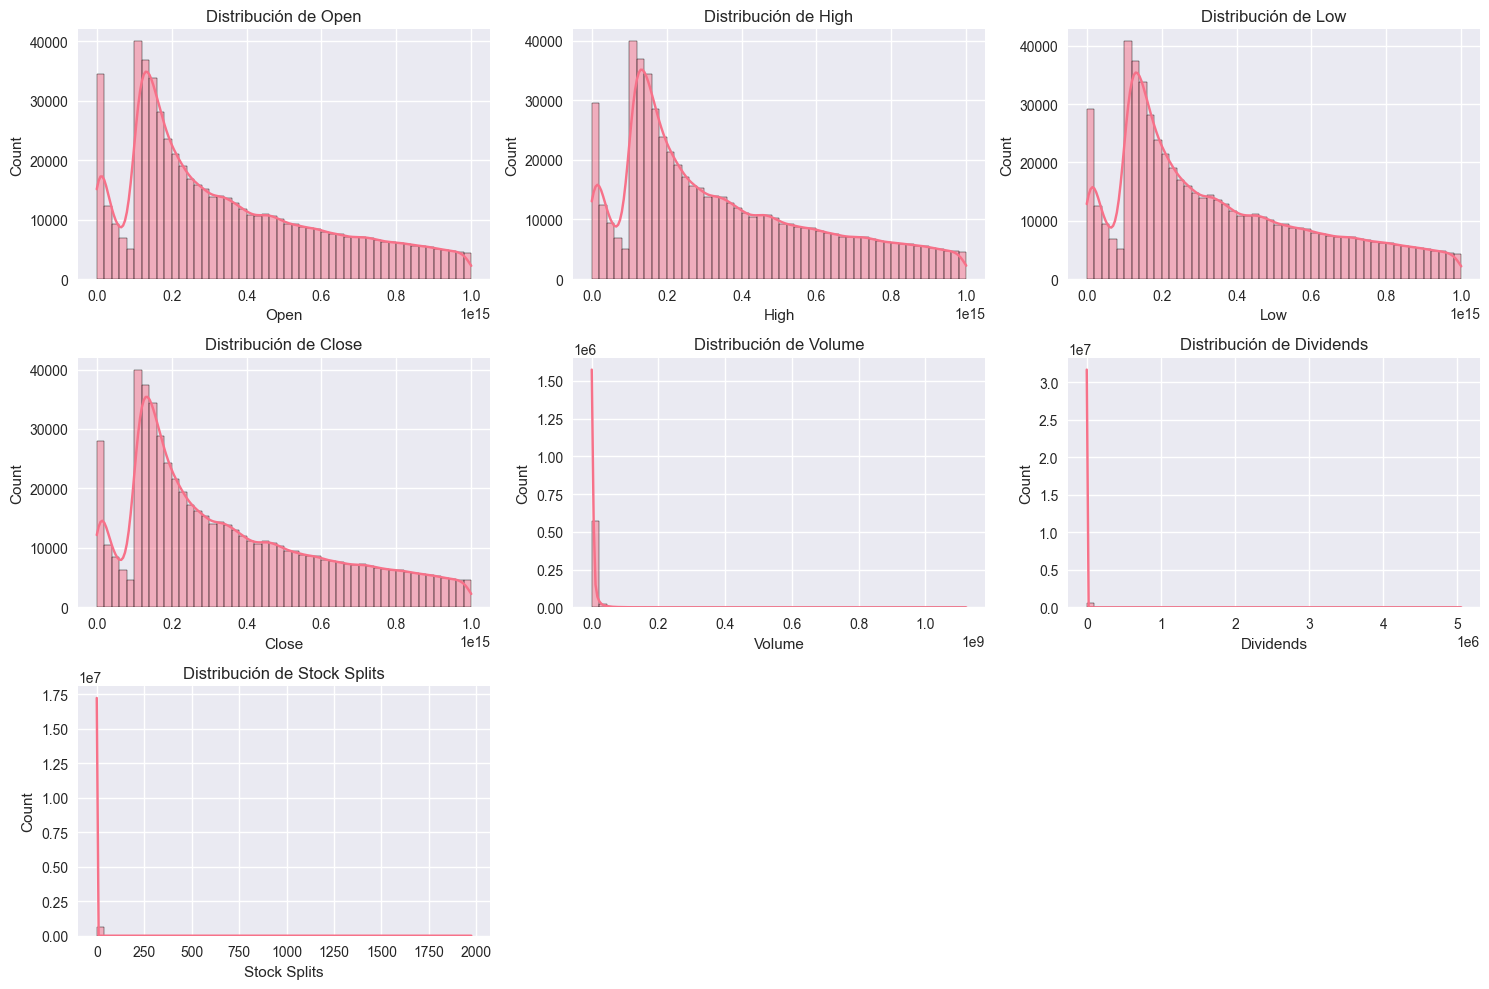

c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(d

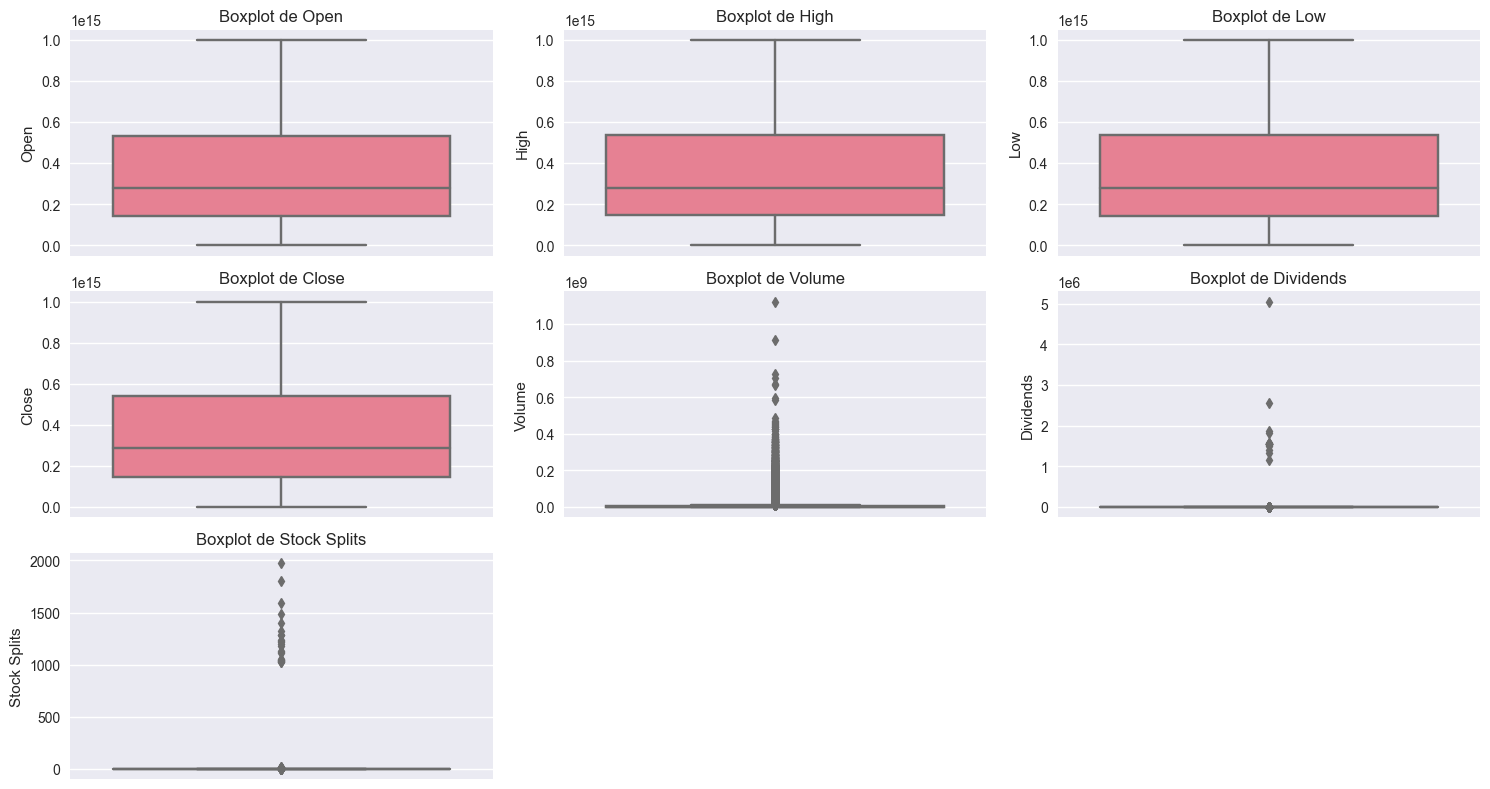


🔎 Detección de outliers (IQR):
Open: 0 posibles outliers
High: 0 posibles outliers
Low: 0 posibles outliers
Close: 0 posibles outliers
Volume: 66419 posibles outliers
Dividends: 6857 posibles outliers
Stock Splits: 71 posibles outliers


In [ ]:

plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    if df[col].nunique() > 1:
        sns.histplot(df[col], kde=True, bins=50)
        plt.title(f'Distribución de {col}')
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    if df[col].nunique() > 1:
        sns.boxplot(y=df[col])
        plt.title(f'Boxplot de {col}')
plt.tight_layout()
plt.show()

print("\n🔎 Detección de outliers (IQR):")
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    print(f"{col}: {len(outliers)} posibles outliers")

## 5. Análisis de Empresas
Se explora cuántas empresas hay y cuáles son las más representadas en el dataset.

In [26]:
print("\n🏢 Análisis de empresas:")
print(f"Empresas únicas: {df['Company'].nunique()}")
print("\nTop 10 empresas con más registros:")
print(df['Company'].value_counts().head(10))


🏢 Análisis de empresas:
Empresas únicas: 491

Top 10 empresas con más registros:
Company
A       1258
NTR     1258
ORAN    1258
ON      1258
OKE     1258
ODFL    1258
O       1258
NXPI    1258
NWG     1258
NVS     1258
Name: count, dtype: int64


## 6. Análisis Bivariado
Se analizan relaciones entre pares de variables numéricas, como correlaciones.


🔗 Análisis bivariado:


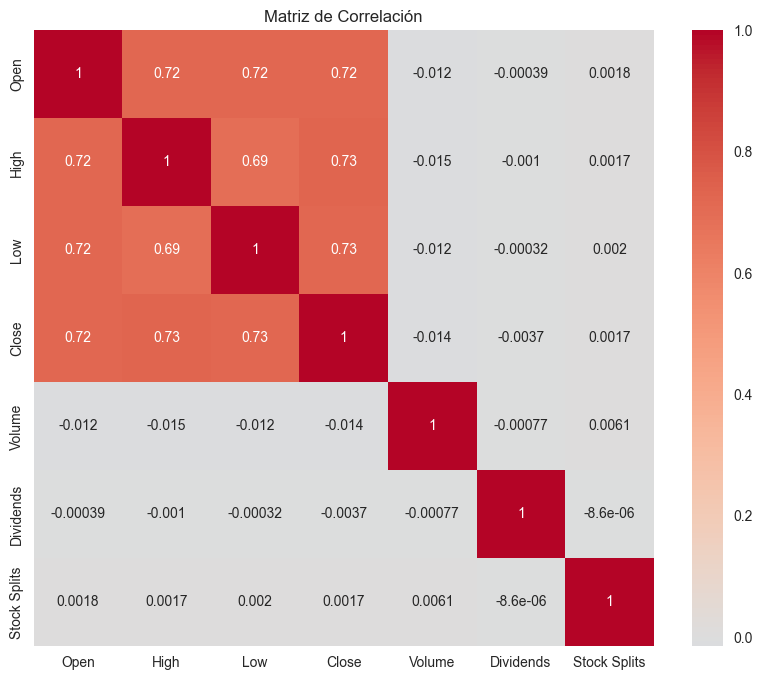

c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


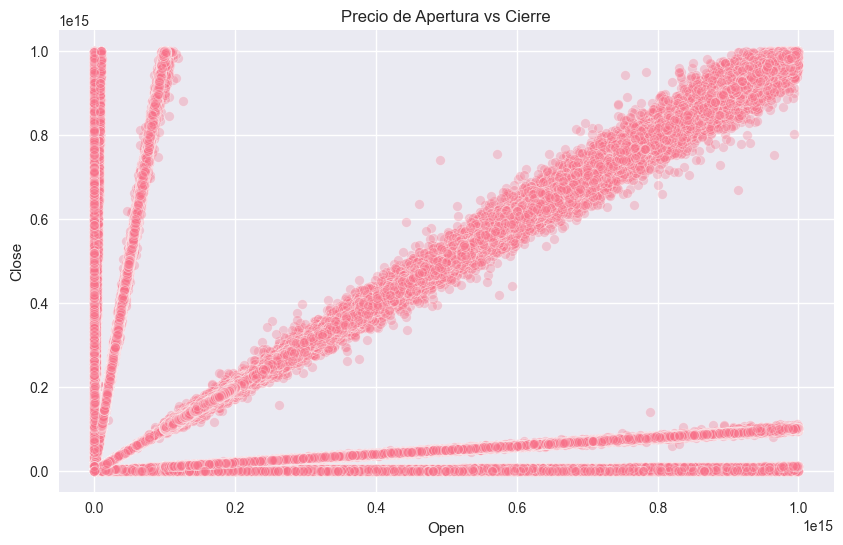

In [27]:
print("\n🔗 Análisis bivariado:")
corr_matrix = df[numeric_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de Correlación')
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Open', y='Close', alpha=0.3)
plt.title('Precio de Apertura vs Cierre')
plt.show()

## 7. Análisis Temporal
Se observa la evolución en el tiempo de precios y volúmenes.


📅 Análisis temporal:


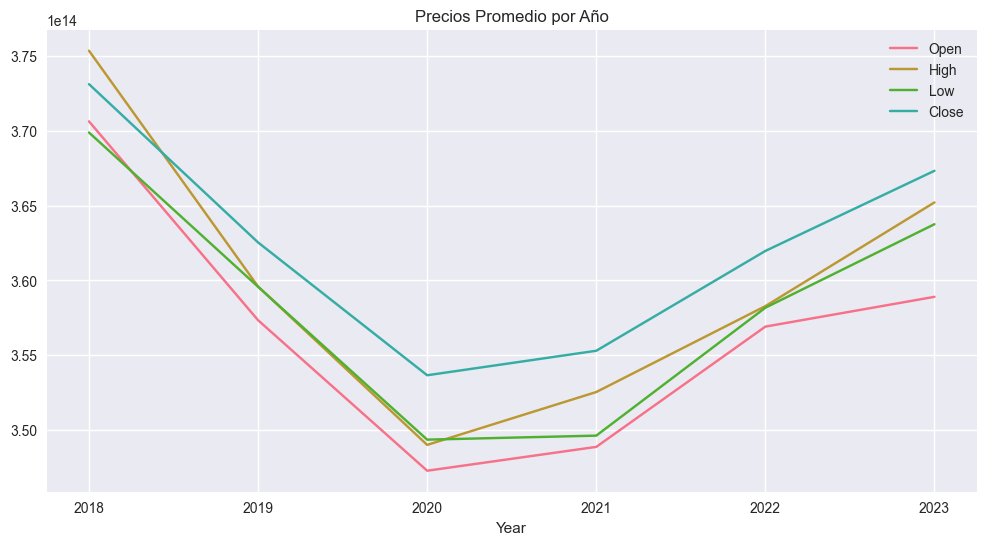

C:\Users\johan\AppData\Local\Temp\ipykernel_36320\1002435345.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Year', y='Volume', estimator=np.sum, ci=None)
c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if 

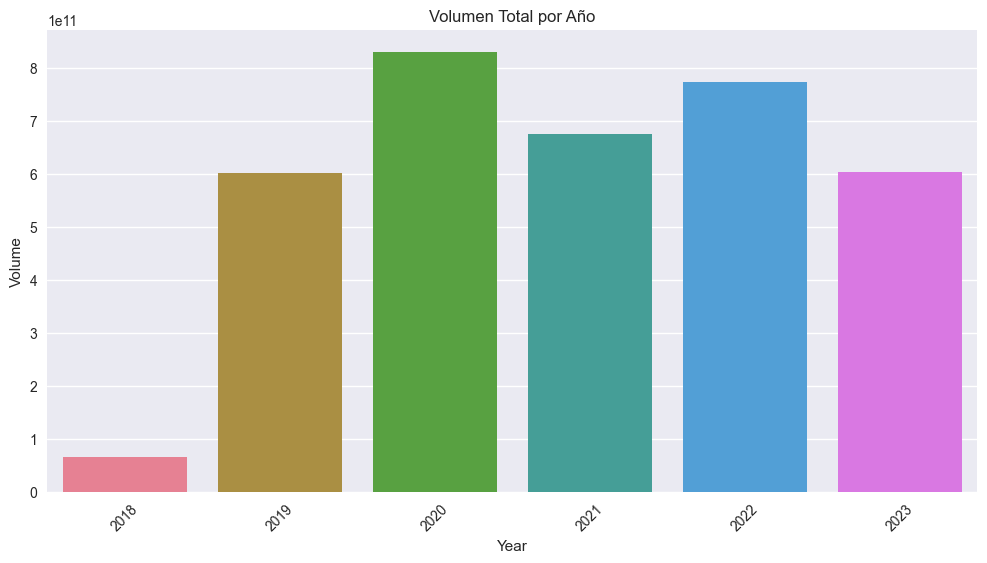

In [28]:
print("\n📅 Análisis temporal:")
df['Year'] = df['Date'].dt.year
yearly_avg = df.groupby('Year')[['Open', 'High', 'Low', 'Close']].mean()
yearly_avg.plot(figsize=(12, 6))
plt.title('Precios Promedio por Año')
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='Year', y='Volume', estimator=np.sum, ci=None)
plt.title('Volumen Total por Año')
plt.xticks(rotation=45)
plt.show()

## 8. Análisis por Empresa
Se analiza la evolución de precios de cierre para las empresas con mayor volumen de operaciones.


🏭 Análisis por empresa:

Top 5 empresas con mayor volumen de operaciones:
Company
TSLA    168480836215
AAPL    130583503785
AMZN     97650968962
AMD      84350178302
F        81579990070
Name: Volume, dtype: int64


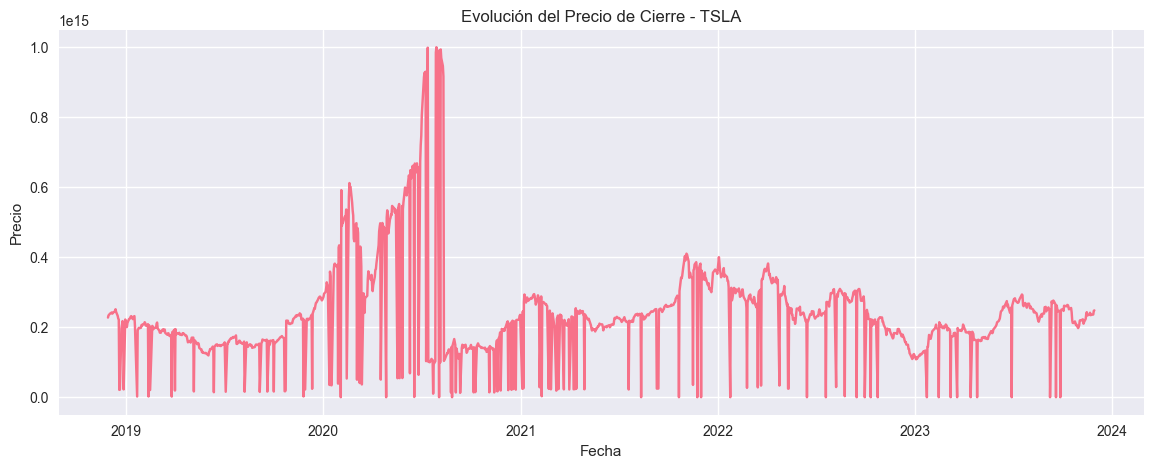

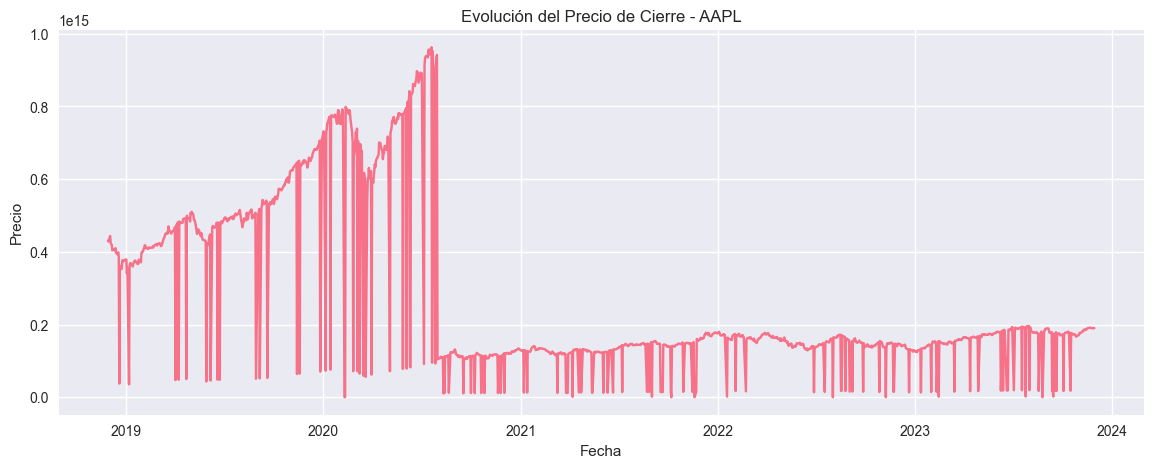

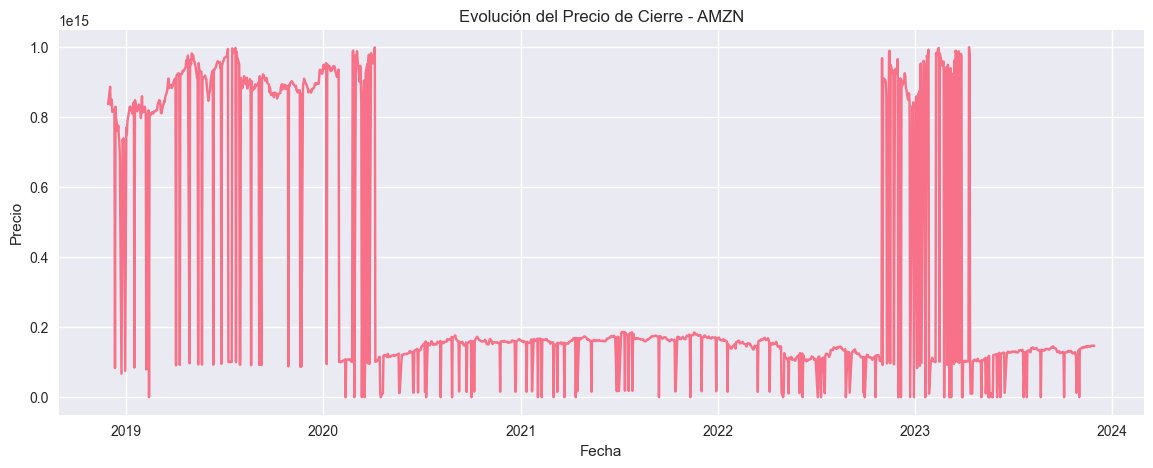

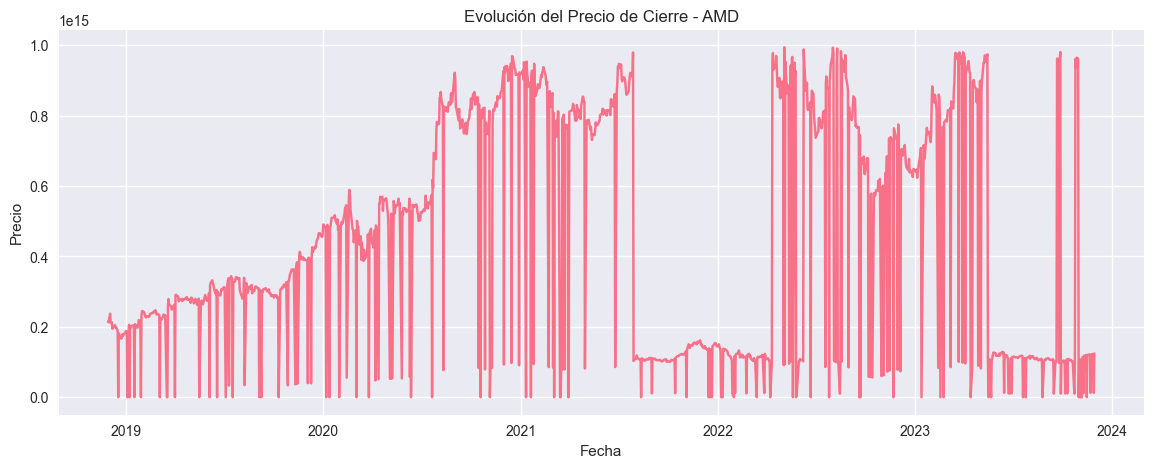

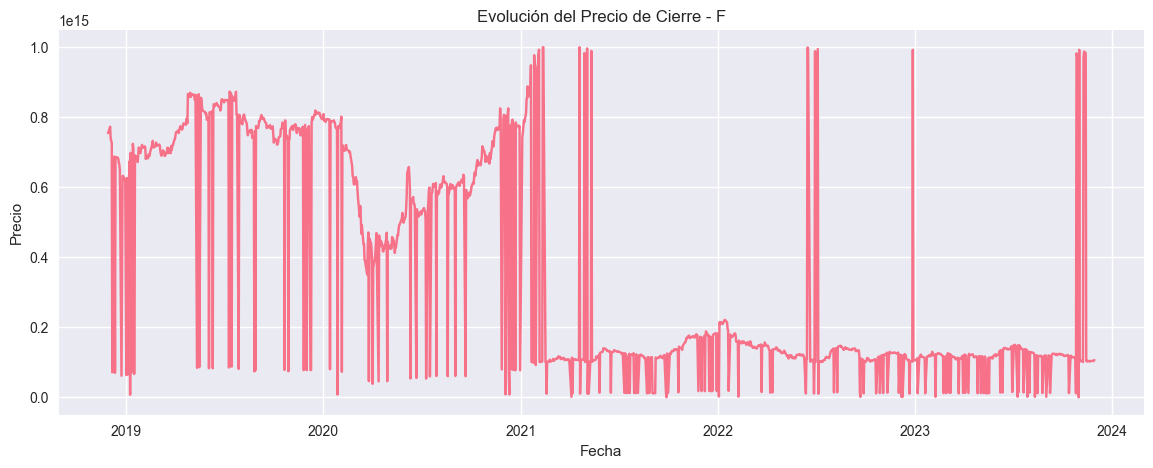

In [29]:
print("\n🏭 Análisis por empresa:")
top_companies = df.groupby('Company')['Volume'].sum().nlargest(5)
print("\nTop 5 empresas con mayor volumen de operaciones:")
print(top_companies)
for company in top_companies.index:
    company_data = df[df['Company'] == company].set_index('Date')
    plt.figure(figsize=(14, 5))
    plt.plot(company_data['Close'])
    plt.title(f'Evolución del Precio de Cierre - {company}')
    plt.ylabel('Precio')
    plt.xlabel('Fecha')
    plt.grid(True)
    plt.show()

## 9. Dividendos y Splits
Se identifican empresas que han pagado dividendos o realizado splits.

In [30]:
print("\n💰 Dividendos y splits:")
print("\nEmpresas que pagaron dividendos:")
print(df[df['Dividends'] > 0]['Company'].unique())
print("\nEmpresas que realizaron splits:")
print(df[df['Stock Splits'] > 0]['Company'].unique())


💰 Dividendos y splits:

Empresas que pagaron dividendos:
['A' 'AAPL' 'ABBV' 'ABEV' 'ABT' 'ACN' 'ADI' 'ADM' 'ADP' 'AEE' 'AEM' 'AEP'
 'AFL' 'AIG' 'AJG' 'ALC' 'ALL' 'AMAT' 'AME' 'AMGN' 'AMP' 'AMT' 'AON' 'APD'
 'APH' 'APO' 'APTV' 'ARES' 'ASML' 'AVB' 'AVGO' 'AWK' 'AXP' 'AZN' 'BA'
 'BAC' 'BBD' 'BBVA' 'BCE' 'BCS' 'BDX' 'BEKE' 'BHP' 'BK' 'BKR' 'BLK' 'BMO'
 'BMY' 'BN' 'BNS' 'BNTX' 'BP' 'BR' 'BRO' 'BSBR' 'BTI' 'BUD' 'BX' 'C' 'CAH'
 'CARR' 'CAT' 'CB' 'CCEP' 'CCI' 'CCJ' 'CCL' 'CDW' 'CEG' 'CHD' 'CHT' 'CI'
 'CL' 'CM' 'CMCSA' 'CME' 'CMI' 'CNI' 'CNQ' 'COF' 'COP' 'COR' 'COST' 'CP'
 'CQP' 'CRH' 'CSCO' 'CSX' 'CTAS' 'CTRA' 'CTSH' 'CTVA' 'CVE' 'CVS' 'CVX'
 'D' 'DAL' 'DB' 'DD' 'DE' 'DELL' 'DEO' 'DFS' 'DG' 'DHI' 'DHR' 'DIS' 'DLR'
 'DOV' 'DOW' 'DTE' 'DUK' 'DVN' 'E' 'EA' 'EBAY' 'EC' 'ECL' 'ED' 'EFX' 'EIX'
 'EL' 'ELP' 'ELV' 'EMR' 'ENB' 'EOG' 'EPD' 'EQIX' 'EQNR' 'EQR' 'ES' 'ET'
 'ETN' 'ETR' 'EXC' 'EXR' 'F' 'FANG' 'FAST' 'FCNCA' 'FCX' 'FDX' 'FE' 'FERG'
 'FIS' 'FITB' 'FMX' 'FNV' 'FTS' 'FTV' 'GD' 'GE' 'GEHC' 'GILD

## 10. Hallazgos Clave
Resumen de observaciones importantes obtenidas durante el EDA.

In [31]:
print("\n🔑 Hallazgos clave del EDA:")
print("1. Precios muestran distribuciones asimétricas.")
print("2. Alta correlación entre Open, High, Low y Close.")
print("3. Volumen altamente sesgado.")
print("4. Pocas empresas pagan dividendos regularmente.")
print("5. Existen valores atípicos que requieren revisión.")
print("6. Precios presentan variaciones y tendencias anuales.")


🔑 Hallazgos clave del EDA:
1. Precios muestran distribuciones asimétricas.
2. Alta correlación entre Open, High, Low y Close.
3. Volumen altamente sesgado.
4. Pocas empresas pagan dividendos regularmente.
5. Existen valores atípicos que requieren revisión.
6. Precios presentan variaciones y tendencias anuales.
